# EDA

## Data Loading

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/data.csv', parse_dates=['Flight_Date'])

# Basic shape and types
print(f"Shape: {df.shape}")
print(df.dtypes)
print(df.head())
print(df.describe())

Shape: (1462, 11)
Unnamed: 0                           int64
Flight_Date                 datetime64[ns]
Route                               object
Carrier                             object
Scheduled_Departure_Time            object
Aircraft_Capacity                    int64
Actual_Pax_Count                     int64
Is_Weekend                            bool
Is_Holiday_Period                     bool
CHML_Ordered                         int64
Flight_ID                           object
dtype: object
   Unnamed: 0 Flight_Date    Route   Carrier Scheduled_Departure_Time  \
0           0  2024-01-01  EDI-DXB  Emirates      2024-01-01 14:00:00   
1           1  2024-01-01  GLA-DXB  Emirates      2024-01-01 20:00:00   
2           2  2024-01-02  EDI-DXB  Emirates      2024-01-02 14:00:00   
3           3  2024-01-02  GLA-DXB  Emirates      2024-01-02 20:00:00   
4           4  2024-01-03  EDI-DXB  Emirates      2024-01-03 14:00:00   

   Aircraft_Capacity  Actual_Pax_Count  Is_Weekend  Is_H

In [53]:
print(len(df)/2, "days of data")

731.0 days of data


In [54]:
#look at missing values

print(df.isnull().sum())

Unnamed: 0                  0
Flight_Date                 0
Route                       0
Carrier                     0
Scheduled_Departure_Time    0
Aircraft_Capacity           0
Actual_Pax_Count            0
Is_Weekend                  0
Is_Holiday_Period           0
CHML_Ordered                0
Flight_ID                   0
dtype: int64


The data consists of 11 columns and 1462 lines. Consisting of two years of SPML data for two different routes.

No missing data

All data types are correct

In [55]:
# Drop the old index column from data 

df.drop('Unnamed: 0', axis=1, inplace =True)

## Target Variable

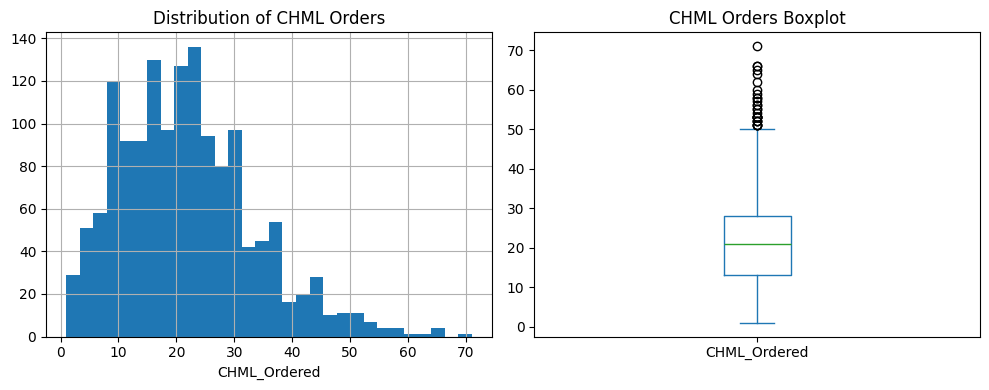

count    1462.000000
mean       21.608755
std        11.573833
min         1.000000
25%        13.000000
50%        21.000000
75%        28.000000
max        71.000000
Name: CHML_Ordered, dtype: float64
Skewness: 0.75


In [56]:
# Distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['CHML_Ordered'].hist(bins=30)
plt.title('Distribution of CHML Orders')
plt.xlabel('CHML_Ordered')

plt.subplot(1, 2, 2)
df['CHML_Ordered'].plot(kind='box')
plt.title('CHML Orders Boxplot')
plt.tight_layout()
plt.show()

# Stats
print(df['CHML_Ordered'].describe())
print(f"Skewness: {df['CHML_Ordered'].skew():.2f}")

In [57]:
print(df[df['CHML_Ordered'] > 51])

     Flight_Date    Route   Carrier Scheduled_Departure_Time  \
193   2024-04-06  GLA-DXB  Emirates      2024-04-06 20:00:00   
197   2024-04-08  GLA-DXB  Emirates      2024-04-08 20:00:00   
361   2024-06-29  GLA-DXB  Emirates      2024-06-29 20:00:00   
373   2024-07-05  GLA-DXB  Emirates      2024-07-05 20:00:00   
381   2024-07-09  GLA-DXB  Emirates      2024-07-09 20:00:00   
385   2024-07-11  GLA-DXB  Emirates      2024-07-11 20:00:00   
387   2024-07-12  GLA-DXB  Emirates      2024-07-12 20:00:00   
397   2024-07-17  GLA-DXB  Emirates      2024-07-17 20:00:00   
407   2024-07-22  GLA-DXB  Emirates      2024-07-22 20:00:00   
411   2024-07-24  GLA-DXB  Emirates      2024-07-24 20:00:00   
417   2024-07-27  GLA-DXB  Emirates      2024-07-27 20:00:00   
419   2024-07-28  GLA-DXB  Emirates      2024-07-28 20:00:00   
431   2024-08-03  GLA-DXB  Emirates      2024-08-03 20:00:00   
449   2024-08-12  GLA-DXB  Emirates      2024-08-12 20:00:00   
569   2024-10-11  GLA-DXB  Emirates     

The range of values is from 0 to 63. The distribution of CHML orders is positively skewed and looks like a poisson distributuion.

All outliers are Glasgow to Dubai flights and all take place during a holiday period

## Categorical Breakdowns

In [58]:
df.groupby('Route')['CHML_Ordered'].agg(['mean', 'std', 'min', 'max', 'count'])

,mean,std,min,max,count
Route,,,,,
EDI-DXB,17.533516,9.437315,1,45,731
GLA-DXB,25.683995,12.073406,4,71,731


The average number of child meals ordered is higher in Glasgow. This would make sense as it is a larger plane

In [59]:
df.groupby('Is_Holiday_Period')['CHML_Ordered'].agg(['mean', 'std', 'min', 'max'])

,mean,std,min,max
Is_Holiday_Period,,,,
False,17.942068,8.648515,1,44
True,33.708824,11.773949,11,71


The number of CHML meals ordered is much higher during Schools holidays

In [60]:
df.groupby('Is_Weekend')['CHML_Ordered'].agg(['mean', 'std', 'min', 'max'])

,mean,std,min,max
Is_Weekend,,,,
False,21.466539,11.565761,1,71
True,21.966346,11.600325,1,65


Whether it is the Weekend or not seems to have little impact on the number of child meals being ordered

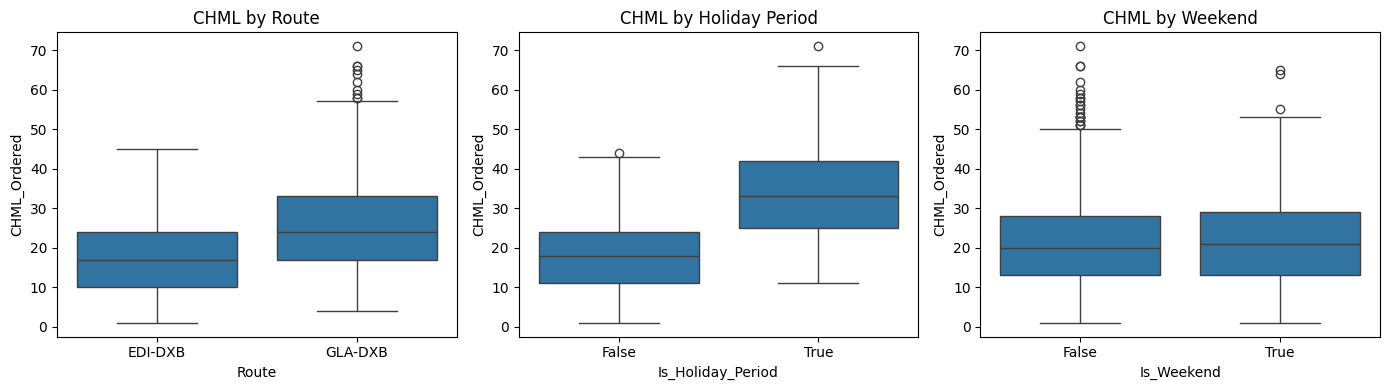

In [61]:
#Visualising the above
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=df, x='Route', y='CHML_Ordered', ax=axes[0])
axes[0].set_title('CHML by Route')

sns.boxplot(data=df, x='Is_Holiday_Period', y='CHML_Ordered', ax=axes[1])
axes[1].set_title('CHML by Holiday Period')

sns.boxplot(data=df, x='Is_Weekend', y='CHML_Ordered', ax=axes[2])
axes[2].set_title('CHML by Weekend')

plt.tight_layout()
plt.show()

## Time Series

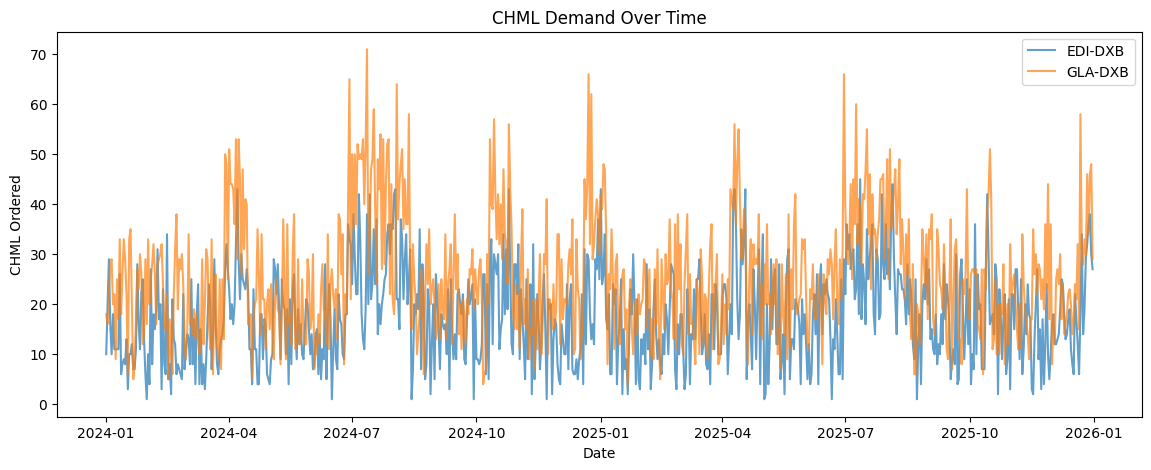

In [62]:
fig, ax = plt.subplots(figsize=(14, 5))

for route in df['Route'].unique():
    route_data = df[df['Route'] == route]
    ax.plot(route_data['Flight_Date'], route_data['CHML_Ordered'], 
            label=route, alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('CHML Ordered')
ax.set_title('CHML Demand Over Time')
ax.legend()
plt.show()

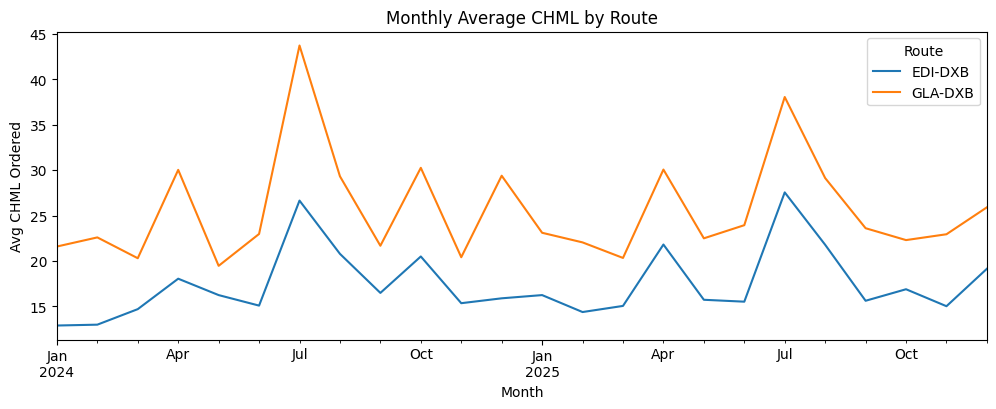

In [63]:
df['Month'] = df['Flight_Date'].dt.to_period('M')
monthly = df.groupby(['Month', 'Route'])['CHML_Ordered'].mean().unstack()
monthly.plot(figsize=(12, 4), title='Monthly Average CHML by Route')
plt.ylabel('Avg CHML Ordered')
plt.show()

Months with long holidays have higher averages. Glasgow always sells more CHMLS than Edinburgh. Peaks in both figures align with school holidays.

## Correlations

                   Aircraft_Capacity  Actual_Pax_Count  CHML_Ordered
Aircraft_Capacity           1.000000          0.989913      0.352229
Actual_Pax_Count            0.989913          1.000000      0.345715
CHML_Ordered                0.352229          0.345715      1.000000


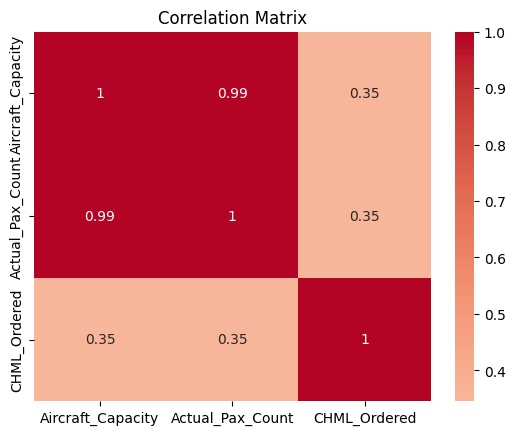

In [64]:
numeric_cols = ['Aircraft_Capacity', 'Actual_Pax_Count', 'CHML_Ordered']
corr = df[numeric_cols].corr()
print(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

Aircraft capacity and actual pax counts are slighty correlated with CHML Order numbers.

## Feature Interactions

Route                EDI-DXB    GLA-DXB
Is_Holiday_Period                      
False              14.737968  21.146168
True               26.758824  40.658824


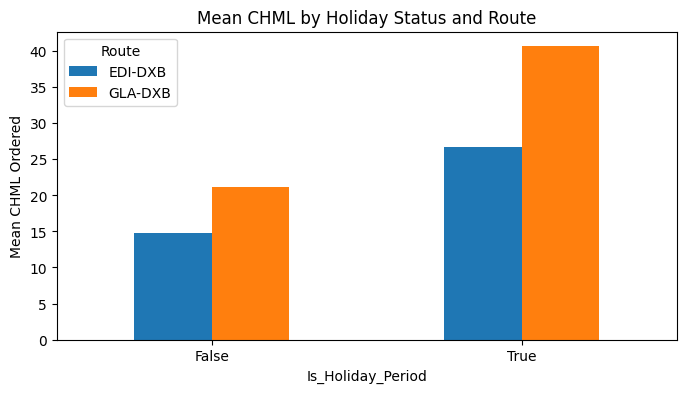

In [65]:
# Holiday + Route interaction
holiday_route = df.groupby(['Is_Holiday_Period', 'Route'])['CHML_Ordered'].mean().unstack()
print(holiday_route)

# Visualise
holiday_route.plot(kind='bar', figsize=(8, 4))
plt.title('Mean CHML by Holiday Status and Route')
plt.ylabel('Mean CHML Ordered')
plt.xticks(rotation=0)
plt.show()

Holiday factor looks to have equal effect for both routes

In [66]:
print(df.columns)

Index(['Flight_Date', 'Route', 'Carrier', 'Scheduled_Departure_Time',
       'Aircraft_Capacity', 'Actual_Pax_Count', 'Is_Weekend',
       'Is_Holiday_Period', 'CHML_Ordered', 'Flight_ID', 'Month'],
      dtype='object')


## Conclusion

Flight Date seems to affect CHML order numbers if the date falls on a holiday. The Glasgow flight has a higher number of meals ordered but this likely because of the larger aircraft. The carrier has no bearing on the target variable as both flights are operated by the same airline. Is_weekend can also be dropped from the model as it looks like it has not effect on the number of CHML ordered.